# The Chaos Game

Author: [Moreno Marzolla](https://www.moreno.marzolla.name/)

Written in March 2026, Last modified May 2026.

---

The chaos game is quite simple but leads to extraordinary resultw. We start with a sheet of paper with three dots marked on it to form the vertices of a triangle. Then, we do the following:

- Mark a random point $z_0$ over the sheet of paper; the point does not need to lie inside the triangle. 
- Choose a random vertex $p_0$ of the triangle
- Let $z_1$ of the segment connecting $z_0$ with $p_0$; Mark $z_1$.
- Choose another random vertex $p_1$ of the triangle, and mark the midpoint $z_2$ of the segment connecting $z_1$ with $p_1$.
- ...

We keep choosing random vertices and marking the midpoint of the segment connecting the last marked point and the chosen vertex. 

What do we get if we repeat the process _forever_? We might think to get a big mess of dots; however, this is not what happens...

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import itertools as it

We define an array `corners` with the coordinates of the corners of the triangle. We represent the coordinates as complex numbers, so we can use addition and division to compute the midpoints.

In [3]:
corners = [0+0j, 1+0j, 0.5+1j];

Now we define a generator `chaos_gen(z0)` that generates an infinite sequence of points using the rules of the Chaos Game, starting from an initial point $z_0$. 

In [4]:
def chaos_gen(z0):
    while True:
        yield(z0)
        p = np.random.choice(corners)
        z0 = (z0+p)/2

Since we can not plot an infinite sequence of numbers, we use [`it.islice`](https://docs.python.org/3/library/itertools.html#itertools.islice) to return an iterator over an initial prefix of the infinite sequence of random points. We can not plot an iterator directly, so we apply function `list()` to get a list of points that can eventually be passed to `plt.plot()`.

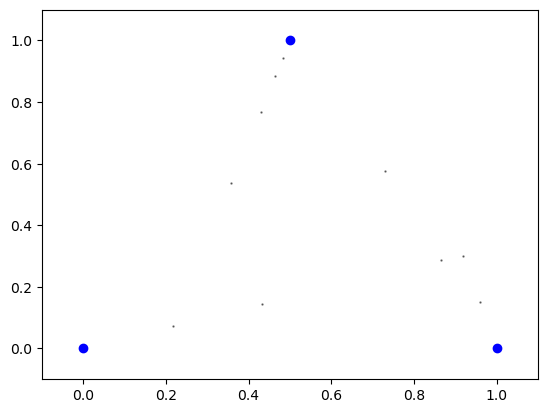

In [5]:
npoints = 10 # how many random points to draw

# Draw the vertices of the triangle
plt.scatter(np.real(corners), np.imag(corners), c='b')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# Initial point on the complex plane
z0 = np.random.rand() + np.random.rand()*1j 
# Iterate `npoints` times the chaos game, starting from z0
points = list(it.islice(chaos_gen(z0), npoints))
# Plot the points
plt.scatter(np.real(points), np.imag(points), c='k', s=0.5, alpha=0.5)
plt.show()

> **Exercise**. What happens when you increase the value of `npoints`?

> **Exercise** 
>    
> 1. Play the chaos game with four initial points instead of three. Arrange the four points as the corners of a square; at each iteration, mark the point lying halfway from the last drawn point and a random corner. What image you get?
>
> 2. Choose a constant $\alpha \in (0,1)$, and apply the chaos game from point 1 above by drawing each point at a fraction $\alpha \in (0,1)$ of the length of the segment from the last drawn point. Specifically, let $z_n$ be the coordinates of the last point drawn, and $p_n$ a random vertex of the square. Then, the coordinates of the next point $z_{n+1}$ will be $z_{n+1} = \alpha z_n + (1- \alpha) p_n$. What image you get?